In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [12]:
X = load_breast_cancer().data

y = load_breast_cancer().target

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size= 0.2,
                                                    random_state = 42,
                                                    #stratify = y
                                                    )

print(f"Train size => {X_train.shape}")
print(f"Target for Train, size => {y_train.shape}")

print(f"Test size => {X_test.shape}")
print(f"Target for Test, size => {y_test.shape}")

Train size => (455, 30)
Target for Train, size => (455,)
Test size => (114, 30)
Target for Test, size => (114,)


In [14]:
model_tree = DecisionTreeClassifier(
    max_depth = 3,
    criterion= 'gini', 
    random_state = 42
)

model_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [15]:
y_pred_test = model_tree.predict(X_test) 
y_pred_train = model_tree.predict(X_train) 

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test) 
 
print("====== Model Evaluation ======")
print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Testing Accuracy: {test_acc*100:.2f}%")


====== Model Evaluation ======
Training Accuracy: 97.80%
Testing Accuracy: 94.74%


In [16]:
cm = confusion_matrix(y_test, y_pred_test)
print("-----------Confusion Matrix----------\n",cm)

-----------Confusion Matrix----------
 [[39  4]
 [ 2 69]]


In [17]:
cr = classification_report(y_test, y_pred_test)
print("----------Classification Report----------\n",cr)

----------Classification Report----------
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        43
           1       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



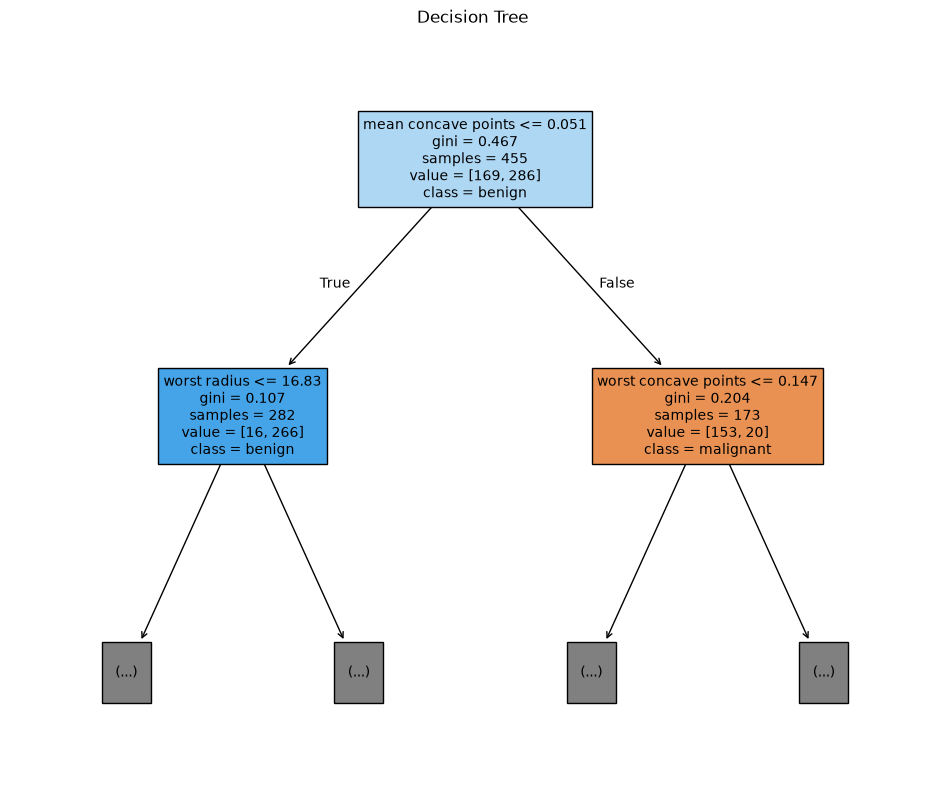

In [18]:
plt.figure(figsize = (12, 10))

plot_tree(model_tree,
          feature_names= load_breast_cancer().feature_names,
          class_names= load_breast_cancer().target_names,
          filled= True,
          max_depth= 1
          )

plt.title("Decision Tree ")
plt.show()

In [19]:
importances = model_tree.feature_importances_
feature_names = load_breast_cancer().feature_names

df_feature_importance = pd.DataFrame({
    'features': feature_names,
    'importance': importances
})

df_top_features = df_feature_importance.sort_values(by= 'importance', ascending= False).head(7)
df_top_features

,features,importance
7,mean concave points,0.752304
27,worst concave points,0.071432
20,worst radius,0.056905
22,worst perimeter,0.056028
1,mean texture,0.030106
19,fractal dimension error,0.020188
13,area error,0.013038


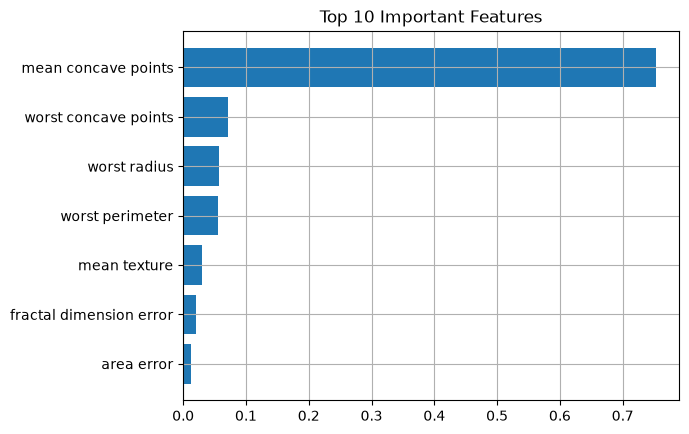

In [20]:
plt.barh(df_top_features['features'], df_top_features['importance'])
plt.gca().invert_yaxis() # invert the axis --- largest on TOP

plt.title("Top 10 Important Features")
plt.grid()
plt.show()